This first script sorts the entire sample into training and testing data. By default, it's an 80/20 split.

In [8]:
import pandas as pd
df = pd.read_csv("Filtered_Bugs_Min4_Frac0.55_Gold-x.csv")
print("Unique values in Split_Labels:", df['Split_Labels'].unique())

Unique values in Split_Labels: <StringArray>
['Insect', 'Other']
Length: 2, dtype: str


In [10]:
import pandas as pd
df = pd.read_csv("Filtered_Bugs_Min4_Frac0.55_Gold-x.csv")
print(df['Split_Labels'].value_counts())

Split_Labels
Insect    82
Other      2
Name: count, dtype: int64


## Augmentation & Split

In [4]:
import os
import shutil
import pandas as pd
import random
import torch
from torchvision.transforms import v2
from PIL import Image

BASE_DIR = os.getcwd()

CSV_FILE = os.path.join(BASE_DIR, "Filtered_Bugs_Min4_Frac0.55_Gold-x.csv")

if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(f"Could not find a valid filtered bugs CSV file at {CSV_FILE}")

SOURCE_DIR = os.path.join(BASE_DIR, "images")
OUTPUT_DIRS = [
    os.path.join(BASE_DIR, "train_balanced", "Insect"),
    os.path.join(BASE_DIR, "train_balanced", "Other"),
    os.path.join(BASE_DIR, "test", "Insect"),
    os.path.join(BASE_DIR, "test", "Other"),
]

def class_from_label(label):
    lbl = str(label).strip().lower()
    if any(bug in lbl for bug in ["thrip", "pirate bug", "insect", "bug"]):
        return "Insect"
    return "Other"

def get_classification(row):
    for col in ("Split_Labels", "Chosen_Label", "InsectIDs"):
        if col in row.index:
            value = row[col]
            if pd.notna(value) and str(value).strip() and str(value).strip().lower() != 'nan':
                if col == "InsectIDs":
                    val_str = str(value)
                    if 'Thrip' in val_str or 'Pirate Bug' in val_str:
                        return "Insect"
                    elif 'Other/Unknown' in val_str or val_str == '':
                        return "Other"
                else:
                    return class_from_label(value)
    return "Other"

for folder in OUTPUT_DIRS:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

print(f"Created folders: {', '.join(OUTPUT_DIRS)}")
print(f"Using CSV: {CSV_FILE}")

df = pd.read_csv(CSV_FILE)
print(f"Total rows found in CSV: {len(df)}")

augmented_filenames = set()
other_filenames = set()

for idx, row in df.iterrows():
    filename = str(row.get('Filename', '')).strip()
    if not filename or filename.lower() == 'nan':
        continue
        
    # Rows 2 through 85 (0-indexed rows 1 to 84) get targeted for selective augmentation
    if 1 <= idx <= 84:
        augmented_filenames.add(filename)
    else:
        other_filenames.add(filename)

print(f"Identified {len(augmented_filenames)} files for selective augmentation (Rows 2-85).")
print(f"Identified {len(other_filenames)} files to include unaugmented.")

file_classes = {}

for _, row in df.iterrows():
    filename = str(row.get('Filename', '')).strip()
    if not filename or filename.lower() == 'nan':
        continue
        
    classification = get_classification(row)
    
    if filename not in file_classes:
        file_classes[filename] = classification
    else:
        if classification == "Insect":
            file_classes[filename] = "Insect"

insects = [f for f, c in file_classes.items() if c == 'Insect']
others = [f for f, c in file_classes.items() if c == 'Other']

print(f"Total unique mapped images -> Insects: {len(insects)} | Others: {len(others)}")

NUM_AUGMENTATIONS = 6 

augmenter = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    
    v2.RandomChoice([
        v2.RandomRotation([0, 0]),     
        v2.RandomRotation([90, 90]),   
        v2.RandomRotation([180, 180]), 
        v2.RandomRotation([270, 270])  
    ]),
    
    v2.Pad(padding=75, padding_mode='reflect'),
    v2.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    v2.CenterCrop(224),
    
    v2.RandomChoice([
        v2.ColorJitter(brightness=(0.8, 1.2), contrast=0.3, saturation=(0.5, 1.5), hue=0.05),
        v2.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 1.0)),
        v2.Lambda(lambda img: img) 
    ]),
    
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True),
    v2.ToPILImage() 
])

resizer = v2.Resize((224, 224), antialias=True)

def augment_and_split(files, class_name):
    print(f"\nProcessing {len(files)} raw {class_name} images...")
    all_variations = []
    
    for f in files:
        all_variations.append((f, 'orig'))
        if f in augmented_filenames:
            for i in range(NUM_AUGMENTATIONS):
                all_variations.append((f, f'aug_{i}'))
            
    random.seed(42)
    random.shuffle(all_variations)
    
    train_count = int(len(all_variations) * 0.8)
    train_files = all_variations[:train_count]
    test_files = all_variations[train_count:]
    
    def process_and_save(item_list, subset_folder):
        count = 0
        for f, v_type in item_list:
            src = os.path.join(SOURCE_DIR, f)
            if not os.path.exists(src):
                continue
                
            img = Image.open(src).convert('RGB')
            
            if v_type == 'orig' or f not in augmented_filenames:
                out_img = resizer(img)
            else:
                out_img = augmenter(img)
                
            out_name = f"{os.path.splitext(f)[0]}_{v_type}.jpg"
            out_path = os.path.join(BASE_DIR, subset_folder, class_name, out_name)
            out_img.save(out_path)
            count += 1
        return count

    print(f" -> Generating and saving images to Train folder...")
    copied_train = process_and_save(train_files, 'train_balanced')
    
    print(f" -> Generating and saving images to Test folder...")
    copied_test = process_and_save(test_files, 'test')

    return copied_train, copied_test

print("\n--- STARTING AUGMENTATION & SPLIT ---")
train_ins, test_ins = augment_and_split(insects, 'Insect')
train_oth, test_oth = augment_and_split(others, 'Other')

print("\n--- PROCESS COMPLETE ---")
print(f"TRAIN SET (80%): {train_ins} Insects | {train_oth} Others")
print(f"TEST SET  (20%): {test_ins} Insects | {test_oth} Others")

Created folders: /Users/ernest/Desktop/RHS Wisley Bug Watch/insect_detection/train_balanced/Insect, /Users/ernest/Desktop/RHS Wisley Bug Watch/insect_detection/train_balanced/Other, /Users/ernest/Desktop/RHS Wisley Bug Watch/insect_detection/test/Insect, /Users/ernest/Desktop/RHS Wisley Bug Watch/insect_detection/test/Other
Using CSV: /Users/ernest/Desktop/RHS Wisley Bug Watch/insect_detection/Filtered_Bugs_Min4_Frac0.55_Gold-x.csv
Total rows found in CSV: 183
Identified 74 files for selective augmentation (Rows 2-85).
Identified 99 files to include unaugmented.
Total unique mapped images -> Insects: 72 | Others: 101

--- STARTING AUGMENTATION & SPLIT ---

Processing 72 raw Insect images...
 -> Generating and saving images to Train folder...
 -> Generating and saving images to Test folder...

Processing 101 raw Other images...
 -> Generating and saving images to Train folder...
 -> Generating and saving images to Test folder...

--- PROCESS COMPLETE ---
TRAIN SET (80%): 356 Insects | 9

## Training & Testing

Using device: cpu
Model weights and evaluations will be saved to: model_results/
Visual prediction overlays will be saved to: model_results/visual_predictions/
Loading datasets...
Initializing model...
Starting training for 25 epochs...
Epoch 1/25 | Train Loss: 0.9255 | Test Loss: 0.8775 | Test Acc: 24.79%
Epoch 2/25 | Train Loss: 0.7652 | Test Loss: 0.7327 | Test Acc: 57.26%
Epoch 3/25 | Train Loss: 0.7403 | Test Loss: 0.7101 | Test Acc: 58.97%
Epoch 4/25 | Train Loss: 0.7087 | Test Loss: 0.7115 | Test Acc: 53.85%
Epoch 5/25 | Train Loss: 0.7050 | Test Loss: 0.6942 | Test Acc: 55.56%
Epoch 6/25 | Train Loss: 0.6962 | Test Loss: 0.7043 | Test Acc: 48.72%
Epoch 7/25 | Train Loss: 0.6740 | Test Loss: 0.6784 | Test Acc: 62.39%
Epoch 8/25 | Train Loss: 0.6820 | Test Loss: 0.6488 | Test Acc: 70.09%
Epoch 9/25 | Train Loss: 0.6756 | Test Loss: 0.6363 | Test Acc: 70.94%
Epoch 10/25 | Train Loss: 0.6590 | Test Loss: 0.6545 | Test Acc: 60.68%
Epoch 11/25 | Train Loss: 0.6400 | Test Loss: 0.6246

,True Label,Predicted Label,Prob: Insect,Prob: Other
0,Insect,Insect,0.612641,0.387359
1,Insect,Insect,0.634996,0.365004
2,Insect,Other,0.470551,0.529449
3,Insect,Insect,0.824122,0.175878
4,Insect,Insect,0.727564,0.272437
...,...,...,...,...
112,Other,Other,0.219591,0.780409
113,Other,Other,0.308912,0.691088
114,Other,Other,0.430594,0.569406
115,Other,Insect,0.596572,0.403428


   True Label Predicted Label  Prob: Insect  Prob: Other
0      Insect          Insect      0.612641     0.387359
1      Insect          Insect      0.634996     0.365004
2      Insect           Other      0.470551     0.529449
3      Insect          Insect      0.824122     0.175878
4      Insect          Insect      0.727564     0.272437
..        ...             ...           ...          ...
95      Other           Other      0.367389     0.632611
96      Other          Insect      0.535904     0.464096
97      Other           Other      0.485963     0.514037
98      Other          Insect      0.759455     0.240545
99      Other          Insect      0.640596     0.359404

[100 rows x 4 columns]

=== PERFORMANCE GRAPHS ===


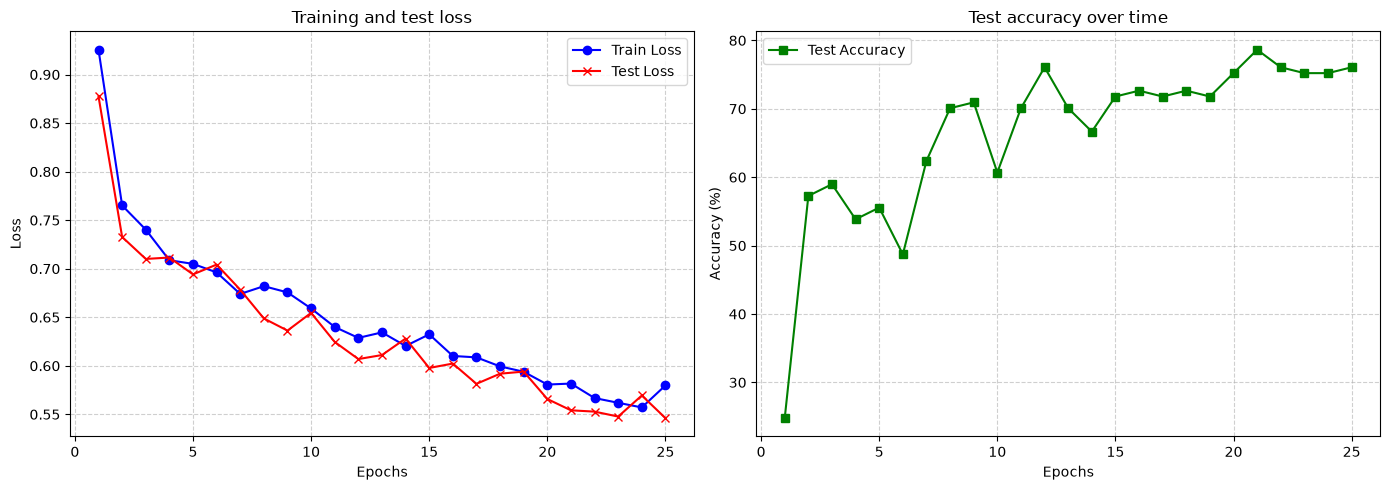

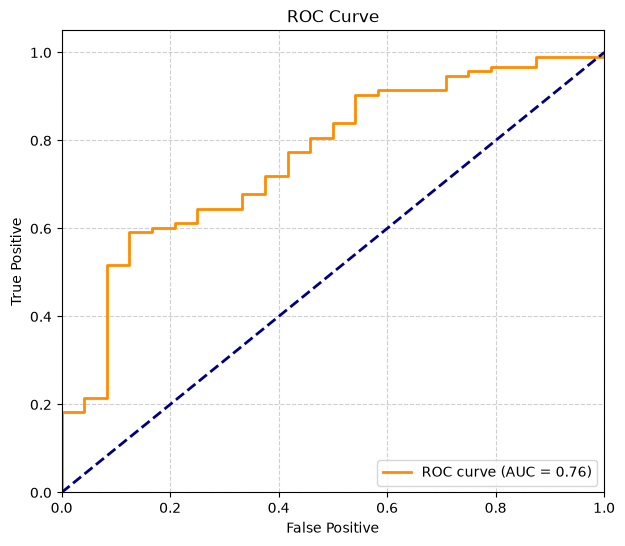

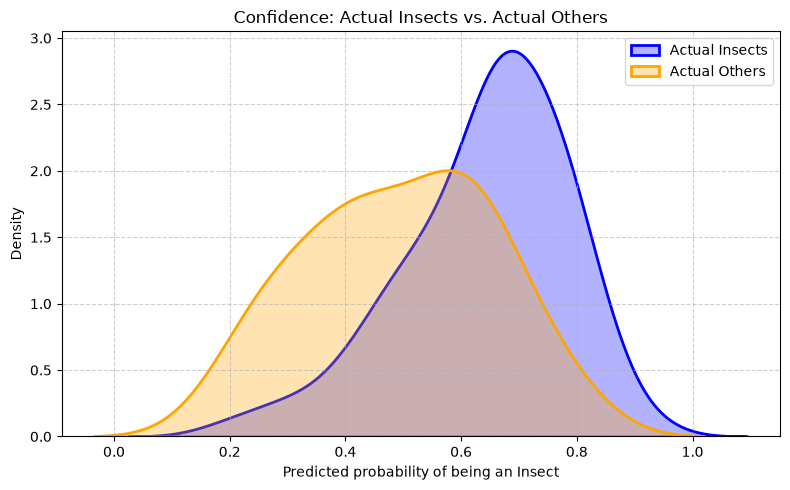

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageDraw, ImageFont

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# # ==========================================
# # 0. DEDICATED MODEL RESULTS FOLDER
# # ==========================================
RESULTS_DIR = "model_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
VISUAL_PREDS_DIR = os.path.join(RESULTS_DIR, "visual_predictions")
os.makedirs(VISUAL_PREDS_DIR, exist_ok=True)
print(f"Model weights and evaluations will be saved to: {RESULTS_DIR}/")
print(f"Visual prediction overlays will be saved to: {VISUAL_PREDS_DIR}/")

# ==========================================
# 1. TRANSFORMS 
# ==========================================
standard_transform = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. LOAD DATASETS
# ==========================================
train_root = "train_balanced"
test_root = "test" 

print("Loading datasets...")
train_ds = datasets.ImageFolder(train_root, transform=standard_transform)
test_ds  = datasets.ImageFolder(test_root, transform=standard_transform)

# ==========================================
# 3. TRAINING SETUP
# ==========================================
insect_class_id = train_ds.class_to_idx['Insect']
other_class_id = train_ds.class_to_idx['Other']

targets = np.array(train_ds.targets)
insect_count = np.sum(targets == insect_class_id)
other_count = np.sum(targets == other_class_id)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Initializing model...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

weights = torch.tensor([1.0, 1.0], dtype=torch.float)
weights[insect_class_id] = other_count / max(1, insect_count)
weights[other_class_id] = 1.0
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
EPOCHS = 25
print(f"Starting training for {EPOCHS} epochs...")

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    train_loss = total_loss / len(train_loader)
    
    # Evaluate on Test Set per Epoch
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            
            loss = criterion(out, y)
            test_loss += loss.item()
            
            probs = torch.softmax(out, dim=1)
            insect_preds = probs[:, insect_class_id] > 0.5
            final_preds = torch.where(insect_preds, 
                                      torch.tensor(insect_class_id, device=device), 
                                      torch.tensor(other_class_id, device=device))
            correct += (final_preds == y).sum().item()
            total += y.size(0)
            
    test_loss = test_loss / len(test_loader)
    test_acc = correct / total
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}")

# # ==========================================
# # 5. SAVE MODEL INFORMATION
# # ==========================================
weights_path = os.path.join(RESULTS_DIR, "model_weights.pth")
torch.save(model.state_dict(), weights_path)
print(f"\nSuccessfully saved model weights to: {weights_path}")

# ==========================================
# 6. EVALUATION & VISUAL OVERLAYS
# ==========================================
print("\nGenerating final report and visual predictions...")
model.eval()
preds, labels_list = [], []

all_true_labels = []
all_pred_labels = []
all_insect_probs = []
all_other_probs = []

test_samples = test_ds.samples

with torch.no_grad():
    batch_idx = 0
    for x, y in test_loader:
        x_dev = x.to(device)
        out = model(x_dev)
        
        probs = torch.softmax(out, dim=1)
        probs_np = probs.cpu().numpy()
        
        insect_preds = (probs[:, insect_class_id] > 0.5).int().cpu().numpy()
        final_preds = np.where(insect_preds == 1, insect_class_id, other_class_id)
        
        preds.extend(final_preds)
        labels_list.extend(y.numpy())
        
        for i in range(len(probs_np)):
            global_idx = batch_idx * test_loader.batch_size + i
            if global_idx < len(test_samples):
                img_path, true_idx = test_samples[global_idx]
                
                insect_prob = probs_np[i][insect_class_id]
                other_prob = probs_np[i][other_class_id]
                
                true_name = 'Insect' if true_idx == insect_class_id else 'Other'
                pred_idx = final_preds[i]
                pred_name = 'Insect' if pred_idx == insect_class_id else 'Other'
                
                all_true_labels.append(true_name)
                all_pred_labels.append(pred_name)
                all_insect_probs.append(insect_prob)
                all_other_probs.append(other_prob)
                
                # --- VISUAL PREDICTION OVERLAY ---
                try:
                    orig_img = Image.open(img_path).convert('RGB')
                    draw = ImageDraw.Draw(orig_img)
                    
                    is_correct = (true_idx == pred_idx)
                    border_color = "green" if is_correct else "red"
                    
                    w, h = orig_img.size
                    draw.rectangle([0, 0, w-1, h-1], outline=border_color, width=6)
                    
                    label_text = f"True: {true_name} | Pred: {pred_name} ({insect_prob:.2f})"
                    draw.rectangle([0, 0, w, 30], fill="black")
                    draw.text((10, 8), label_text, fill="white")
                    
                    base_filename = os.path.basename(img_path)
                    save_name = f"pred_{'correct' if is_correct else 'wrong'}_{base_filename}"
                    orig_img.save(os.path.join(VISUAL_PREDS_DIR, save_name))
                except Exception as e:
                    pass
                    
        batch_idx += 1

print(f"\nSuccessfully generated visual comparison images in: {VISUAL_PREDS_DIR}/")

print("\n=== CLASSIFICATION REPORT ===")
report_str = classification_report(labels_list, preds, target_names=['Insect', 'Other'])
print(report_str)

report_path = os.path.join(RESULTS_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report_str)

print("\n=== FULL PROBABILITY ARRAY ===")
probability_df = pd.DataFrame({
    'True Label': all_true_labels,
    'Predicted Label': all_pred_labels,
    'Prob: Insect': all_insect_probs,
    'Prob: Other': all_other_probs
})

csv_results_path = os.path.join(RESULTS_DIR, "probability_results.csv")
probability_df.to_csv(csv_results_path, index=False)
display(probability_df)
print(probability_df.head(100))

# # ==========================================
# # 7. PLOT GRAPHS
# # ==========================================
print("\n=== PERFORMANCE GRAPHS ===")

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, EPOCHS + 1), test_losses, label='Test Loss', color='red', marker='x')
plt.title('Training and test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
plt.subplot(1, 2, 2)
acc_percentages = [acc * 100 for acc in test_accuracies]
plt.plot(range(1, EPOCHS + 1), acc_percentages, label='Test Accuracy', color='green', marker='s')
plt.title('Test accuracy over time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "loss_and_accuracy_curves.png"))
plt.show()

# ROC Curve
binary_true_labels = [1 if label == 'Insect' else 0 for label in all_true_labels]
fpr, tpr, thresholds = roc_curve(binary_true_labels, all_insect_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(RESULTS_DIR, "roc_curve.png"))
plt.show()

# Probability Distribution Plots

true_insect_scores = [prob for prob, true_lbl in zip(all_insect_probs, all_true_labels) if true_lbl == 'Insect']
true_other_scores = [prob for prob, true_lbl in zip(all_insect_probs, all_true_labels) if true_lbl == 'Other']

plt.figure(figsize=(8, 5))
sns.kdeplot(true_insect_scores, color='blue', label='Actual Insects', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(true_other_scores, color='orange', label='Actual Others', fill=True, alpha=0.3, linewidth=2)
plt.title('Confidence: Actual Insects vs. Actual Others')
plt.xlabel('Predicted probability of being an Insect')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "probability_density_overlap.png"))
plt.show()

## Analysis and Evaluation

(will soon update and make more modular)